# 加州房价预测：线性回归与正则化

本项目使用 California Housing 数据建立房价回归模型，重点展示一套规范且可复现的实验流程：

1. 提前隔离独立测试集；
2. 只使用开发集进行探索、特征工程和模型选择；
3. 使用统一的预处理 Pipeline 防止数据泄漏；
4. 通过 5 折交叉验证比较线性回归、Ridge 与 Lasso；
5. 模型确定后，仅在测试集上评估一次。

评价指标以 RMSE 为主，同时报告 MAE 与 $R^2$。RMSE 对大误差更敏感，适合衡量房价预测偏差。

In [1]:
from pathlib import Path
import shutil
import tarfile
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)

## 1. 获取并校验数据

原始数据包含 20,640 个加州街区，目标变量为 `median_house_value`。代码使用 Python 标准库下载压缩包并只提取 `housing.csv`，不依赖系统的 `wget` 或 `tar` 命令。

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

DATA_URL = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.tgz"
ARCHIVE_PATH = DATA_DIR / "housing.tgz"
CSV_PATH = DATA_DIR / "housing.csv"

if not CSV_PATH.exists():
    print("正在下载 California Housing 数据……")
    urllib.request.urlretrieve(DATA_URL, ARCHIVE_PATH)
    with tarfile.open(ARCHIVE_PATH, "r:gz") as archive:
        member = archive.getmember("housing.csv")
        source = archive.extractfile(member)
        if source is None:
            raise RuntimeError("压缩包中未找到 housing.csv")
        with source, CSV_PATH.open("wb") as target:
            shutil.copyfileobj(source, target)
    ARCHIVE_PATH.unlink(missing_ok=True)

df = pd.read_csv(CSV_PATH)

required_columns = {
    "longitude", "latitude", "housing_median_age", "total_rooms",
    "total_bedrooms", "population", "households", "median_income",
    "median_house_value", "ocean_proximity",
}
assert required_columns.issubset(df.columns), "数据字段不完整"
assert len(df) == 20_640, "数据行数与预期不符"

print(f"数据规模：{df.shape[0]:,} 行 × {df.shape[1]} 列")
df.head()

数据规模：20,640 行 × 10 列


   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  

In [3]:
quality_report = pd.DataFrame({
    "数据类型": df.dtypes.astype(str),
    "缺失数量": df.isna().sum(),
    "缺失比例": (df.isna().mean() * 100).round(2),
    "唯一值数量": df.nunique(),
})

print(f"重复行数量：{df.duplicated().sum()}")
quality_report

重复行数量：0


                       数据类型  缺失数量  缺失比例  唯一值数量
longitude           float64     0   0.0    844
latitude            float64     0   0.0    862
housing_median_age  float64     0   0.0     52
total_rooms         float64     0   0.0   5926
total_bedrooms      float64   207   1.0   1923
population          float64     0   0.0   3888
households          float64     0   0.0   1815
median_income       float64     0   0.0  12928
median_house_value  float64     0   0.0   3842
ocean_proximity      object     0   0.0      5

数据中只有 `total_bedrooms` 存在少量缺失值；缺失值填补将在交叉验证 Pipeline 内完成，填补统计量只从对应训练折计算。

## 2. 隔离独立测试集

先按收入区间进行分层抽样，将 20% 数据固定为测试集。此后所有探索和模型选择都只使用开发集，直到最终模型确定。

In [4]:
income_group = pd.cut(
    df["median_income"],
    bins=[0, 1.5, 3.0, 4.5, 6.0, np.inf],
    labels=False,
)

dev_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=income_group,
)

X_dev = dev_df.drop(columns="median_house_value")
y_dev = dev_df["median_house_value"].copy()
X_test = test_df.drop(columns="median_house_value")
y_test = test_df["median_house_value"].copy()

print(f"开发集：{len(X_dev):,} 条")
print(f"测试集：{len(X_test):,} 条（在最终评估前不使用）")

开发集：16,512 条
测试集：4,128 条（在最终评估前不使用）


## 3. 开发集探索

探索性分析只查看开发集。房价和收入均呈右偏分布；经纬度显示高价区域主要集中在沿海及主要城市附近。

In [5]:
dev_summary = dev_df.describe(include="all").T
dev_summary[[column for column in ["count", "mean", "std", "min", "50%", "max", "unique", "top"] if column in dev_summary.columns]]

                      count           mean           std      min       50%  \
longitude           16512.0    -119.575635      2.001828  -124.35   -118.51   
latitude            16512.0      35.639314      2.137963    32.54     34.26   
housing_median_age  16512.0      28.653404     12.574819      1.0      29.0   
total_rooms         16512.0    2622.539789    2138.41708      6.0    2119.0   
total_bedrooms      16354.0     534.914639    412.665649      2.0     433.0   
population          16512.0    1419.687379   1115.663036      3.0    1164.0   
households          16512.0      497.01181    375.696156      2.0     408.0   
median_income       16512.0       3.875884      1.904931   0.4999   3.54155   
median_house_value  16512.0  207005.322372  115701.29725  14999.0  179500.0   
ocean_proximity       16512            NaN           NaN      NaN       NaN   

                         max unique        top  
longitude            -114.31    NaN        NaN  
latitude               41.95    

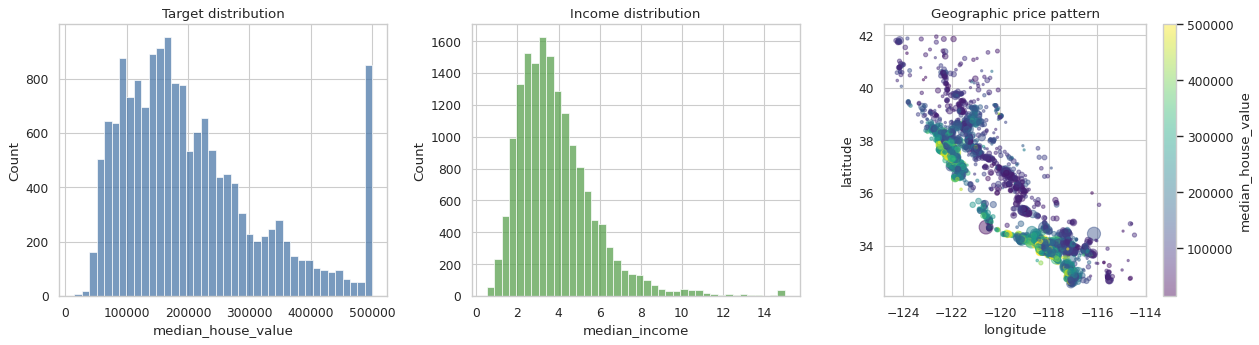

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(dev_df["median_house_value"], bins=40, ax=axes[0], color="#4C78A8")
axes[0].set(title="Target distribution", xlabel="median_house_value")

sns.histplot(dev_df["median_income"], bins=40, ax=axes[1], color="#59A14F")
axes[1].set(title="Income distribution", xlabel="median_income")

sample = dev_df.sample(n=min(6_000, len(dev_df)), random_state=RANDOM_STATE)
scatter = axes[2].scatter(
    sample["longitude"], sample["latitude"],
    c=sample["median_house_value"], cmap="viridis",
    s=np.maximum(sample["population"] / 80, 4), alpha=0.45,
)
axes[2].set(title="Geographic price pattern", xlabel="longitude", ylabel="latitude")
fig.colorbar(scatter, ax=axes[2], label="median_house_value")

plt.tight_layout()
plt.show()

## 4. 特征工程

新增特征全部由单条记录直接计算，不依赖全体样本统计量，因此可以在划分后安全应用：

- `rooms_per_household`：每户房间数；
- `bedrooms_per_room`：卧室占全部房间的比例；
- `population_per_household`：每户人口；
- `median_income_squared`：收入的二次项；
- `distance_to_sf`、`distance_to_la`：到旧金山和洛杉矶的简化经纬度距离。

In [7]:
def add_features(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    result["rooms_per_household"] = result["total_rooms"] / result["households"]
    result["bedrooms_per_room"] = result["total_bedrooms"] / result["total_rooms"]
    result["population_per_household"] = result["population"] / result["households"]
    result["median_income_squared"] = result["median_income"] ** 2
    result["distance_to_sf"] = np.hypot(result["longitude"] + 122.4, result["latitude"] - 37.8)
    result["distance_to_la"] = np.hypot(result["longitude"] + 118.2, result["latitude"] - 34.1)
    return result


X_dev_fe = add_features(X_dev)
X_test_fe = add_features(X_test)

assert np.isfinite(X_dev_fe.drop(columns="ocean_proximity").dropna()).all().all()
print(f"特征数量：{X_dev.shape[1]} → {X_dev_fe.shape[1]}")
X_dev_fe.head()

特征数量：9 → 15


       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
12655    -121.46     38.52                29.0       3873.0           797.0   
15502    -117.23     33.09                 7.0       5320.0           855.0   
2908     -119.04     35.37                44.0       1618.0           310.0   
14053    -117.13     32.75                24.0       1877.0           519.0   
20496    -118.70     34.28                27.0       3536.0           646.0   

       population  households  median_income ocean_proximity  \
12655      2237.0       706.0         2.1736          INLAND   
15502      2015.0       768.0         6.3373      NEAR OCEAN   
2908        667.0       300.0         2.8750          INLAND   
14053       898.0       483.0         2.2264      NEAR OCEAN   
20496      1837.0       580.0         4.4964       <1H OCEAN   

       rooms_per_household  bedrooms_per_room  population_per_household  \
12655             5.485836           0.205784                  3.

## 5. 统一预处理 Pipeline

数值特征使用中位数填补并标准化；类别特征使用众数填补和 one-hot 编码。所有预处理步骤都在每个交叉验证训练折内拟合。

In [8]:
numeric_columns = X_dev_fe.select_dtypes(include="number").columns.tolist()
categorical_columns = X_dev_fe.select_dtypes(exclude="number").columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_columns),
    ("categorical", categorical_pipeline, categorical_columns),
])

model_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LinearRegression()),
])

print(f"数值特征：{len(numeric_columns)} 个")
print(f"类别特征：{len(categorical_columns)} 个")

数值特征：14 个
类别特征：1 个


## 6. 交叉验证选择模型

使用相同的 5 折划分比较四类候选方案：

- 中位数预测基线；
- 普通线性回归；
- Ridge（L2 正则化）；
- Lasso（L1 正则化）。

Ridge 和 Lasso 的正则化强度也只通过开发集交叉验证选择。测试集不参与这一过程。

In [9]:
parameter_grid = [
    {"model": [DummyRegressor(strategy="median")]},
    {"model": [LinearRegression()]},
    {
        "model": [Ridge()],
        "model__alpha": np.logspace(-2, 4, 13),
    },
    {
        "model": [Lasso(max_iter=20_000)],
        "model__alpha": [1.0, 10.0, 100.0, 1_000.0],
    },
]

search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=parameter_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    refit=True,
    return_train_score=False,
)
search.fit(X_dev_fe, y_dev)

print("交叉验证完成。")

交叉验证完成。


In [10]:
cv_results = pd.DataFrame(search.cv_results_)
cv_results["model_name"] = cv_results["param_model"].map(lambda model: type(model).__name__)
cv_results["alpha"] = [params.get("model__alpha", np.nan) for params in cv_results["params"]]
cv_results["CV_RMSE"] = -cv_results["mean_test_score"]
cv_results["CV_STD"] = cv_results["std_test_score"]

best_by_model = (
    cv_results
    .sort_values("CV_RMSE")
    .groupby("model_name", as_index=False)
    .first()[["model_name", "alpha", "CV_RMSE", "CV_STD", "mean_fit_time"]]
    .sort_values("CV_RMSE")
    .reset_index(drop=True)
)

best_by_model.round({"alpha": 4, "CV_RMSE": 0, "CV_STD": 0, "mean_fit_time": 2})

         model_name  alpha   CV_RMSE  CV_STD  mean_fit_time
0             Lasso  100.0   67473.0   628.0           0.05
1             Ridge   10.0   67483.0   617.0           0.04
2  LinearRegression    NaN   67486.0   614.0           0.07
3    DummyRegressor    NaN  118937.0   857.0           0.07

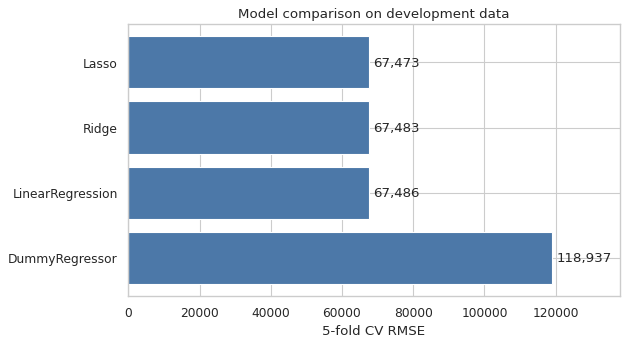

In [11]:
plt.figure(figsize=(8, 4.5))
plot_data = best_by_model.sort_values("CV_RMSE", ascending=False)
bars = plt.barh(plot_data["model_name"], plot_data["CV_RMSE"], color="#4C78A8")
plt.xlabel("5-fold CV RMSE")
plt.title("Model comparison on development data")
plt.bar_label(bars, labels=[f"{value:,.0f}" for value in plot_data["CV_RMSE"]], padding=4)
plt.xlim(0, plot_data["CV_RMSE"].max() * 1.16)
plt.tight_layout()
plt.show()

## 7. 锁定最终模型

`GridSearchCV` 已根据平均交叉验证 RMSE 选择唯一方案，并使用全部开发集重新拟合。到此为止模型结构和超参数已经固定。

In [12]:
selected_model = search.best_estimator_.named_steps["model"]
selected_name = type(selected_model).__name__
selected_alpha = getattr(selected_model, "alpha", None)

print(f"最终模型：{selected_name}")
if selected_alpha is not None:
    print(f"正则化参数 alpha：{selected_alpha:g}")
print(f"最佳交叉验证 RMSE：{-search.best_score_:,.0f}")

最终模型：Lasso
正则化参数 alpha：100
最佳交叉验证 RMSE：67,473


## 8. 独立测试集最终评估

下面是本项目第一次也是唯一一次计算测试集预测。此结果不再用于返回调整特征、模型或参数。

In [13]:
test_prediction = search.best_estimator_.predict(X_test_fe)

test_rmse = mean_squared_error(y_test, test_prediction) ** 0.5
test_mae = mean_absolute_error(y_test, test_prediction)
test_r2 = r2_score(y_test, test_prediction)

final_metrics = pd.DataFrame({
    "指标": ["RMSE", "MAE", "R²"],
    "数值": [test_rmse, test_mae, test_r2],
})

assert np.isfinite(test_prediction).all()
assert test_rmse > 0

print(f"Test RMSE：{test_rmse:,.0f}")
print(f"Test MAE ：{test_mae:,.0f}")
print(f"Test R²  ：{test_r2:.3f}")
final_metrics

Test RMSE：66,349
Test MAE ：48,820
Test R²  ：0.662


     指标            数值
0  RMSE  66349.065025
1   MAE  48819.902018
2    R²      0.662231

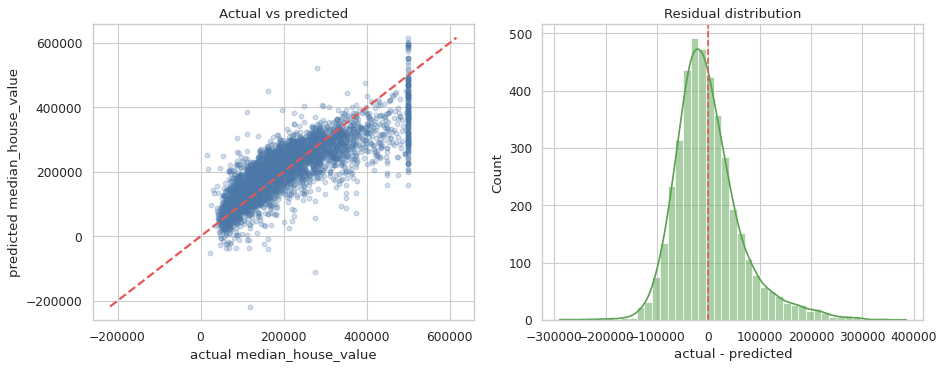

In [14]:
residuals = y_test.to_numpy() - test_prediction

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

axes[0].scatter(y_test, test_prediction, alpha=0.25, s=18, color="#4C78A8")
limits = [min(y_test.min(), test_prediction.min()), max(y_test.max(), test_prediction.max())]
axes[0].plot(limits, limits, "--", color="#E45756", linewidth=2)
axes[0].set(
    title="Actual vs predicted",
    xlabel="actual median_house_value",
    ylabel="predicted median_house_value",
)

sns.histplot(residuals, bins=45, kde=True, ax=axes[1], color="#59A14F")
axes[1].axvline(0, linestyle="--", color="#E45756")
axes[1].set(title="Residual distribution", xlabel="actual - predicted")

plt.tight_layout()
plt.show()

## 9. 系数分析

若最终方案是线性回归、Ridge 或 Lasso，可以查看标准化数值特征及类别哑变量对应的系数。系数绝对值反映模型中的关联强度，但不代表因果关系。

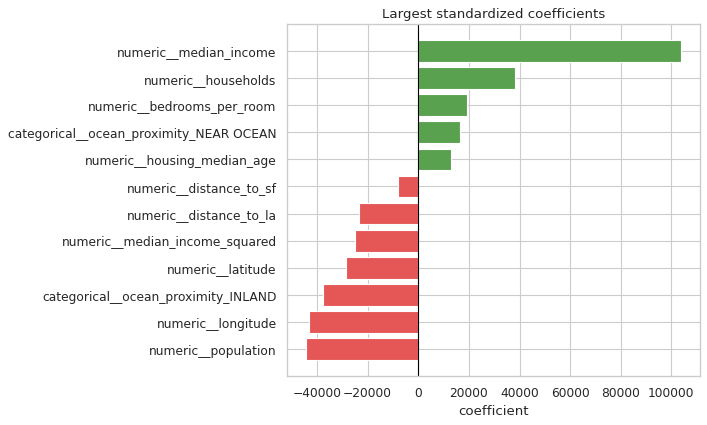

                                    feature    coefficient
7                    numeric__median_income  103840.433843
6                       numeric__households   38280.076960
9                numeric__bedrooms_per_room   19365.259259
18  categorical__ocean_proximity_NEAR OCEAN   16425.099571
2               numeric__housing_median_age   13121.457892
12                  numeric__distance_to_sf   -7850.977520
13                  numeric__distance_to_la  -23335.195027
11           numeric__median_income_squared  -24956.581458
1                         numeric__latitude  -28632.700010
15      categorical__ocean_proximity_INLAND  -37795.754843
0                        numeric__longitude  -43199.124600
5                       numeric__population  -44388.974632

In [15]:
if hasattr(selected_model, "coef_"):
    feature_names = search.best_estimator_.named_steps["preprocess"].get_feature_names_out()
    coefficient_table = (
        pd.DataFrame({"feature": feature_names, "coefficient": selected_model.coef_})
        .assign(abs_coefficient=lambda table: table["coefficient"].abs())
        .sort_values("abs_coefficient", ascending=False)
        .head(12)
        .sort_values("coefficient")
    )

    plt.figure(figsize=(9, 5.5))
    colors = np.where(coefficient_table["coefficient"] >= 0, "#59A14F", "#E45756")
    plt.barh(coefficient_table["feature"], coefficient_table["coefficient"], color=colors)
    plt.axvline(0, color="black", linewidth=1)
    plt.xlabel("coefficient")
    plt.title("Largest standardized coefficients")
    plt.tight_layout()
    plt.show()

    display(coefficient_table[["feature", "coefficient"]].sort_values("coefficient", ascending=False))
else:
    print("最终模型不提供线性系数。")

## 10. 结论与局限

- 本项目将数据预处理、模型训练和超参数选择放在同一 Pipeline 中，避免了验证折信息泄漏。
- 模型选择完全依据开发集的 5 折交叉验证结果；独立测试集只用于最终一次评估。
- 比例特征、收入二次项和城市距离为线性模型补充了有限的非线性与地理信息。
- 目标房价在约 50 万美元处存在人为上限，线性模型在高价区域会产生系统误差。
- 经纬度直线距离只是简化特征；真实估价还需要交通、学校、社区和时间变化等信息。

后续若追求更低误差，可以在保持相同测试集隔离原则的前提下，比较树模型或梯度提升模型。